# **AI Resume Screening & Job Recommendation**

# 1. **Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 2. **Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 3. **Load Dataset**

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AI_Resume_Screening_Project/Resume_Dataset.csv')

# 4. **Data Understanding**


In [4]:
df.head() # Display the first five rows

,Resume,Category
0,Python Developer Python Developer Philadelphia...,Python_Developer
1,Python Developer Python Developer Python Devel...,Python_Developer
2,R&D Engineer R&D Engineer R&D Engineer - Nokia...,Python_Developer
3,Sr. Full Stack Developer Sr. Full Stack Develo...,Python_Developer
4,Sr. Full Stack Python Developer Sr. Full Stack...,Python_Developer


In [5]:
df.shape  # Check dataset dimensions

(8234, 2)

In [6]:
df.columns # Display column names

Index(['Resume', 'Category'], dtype='object')

In [7]:
df.info() # Dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8234 entries, 0 to 8233
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Resume    8234 non-null   object
 1   Category  8234 non-null   object
dtypes: object(2)
memory usage: 128.8+ KB


In [8]:
df.describe() # Statistical summary

,Resume,Category
count,8234,8234
unique,8167,10
top,Systems Administrator Systems Administrator Sy...,Python_Developer
freq,2,1278


# 5. **Data Cleaning**

In [9]:
df.isnull().sum() # Check Missing Values

,0
Resume,0
Category,0


In [10]:
df.duplicated().sum() # Check Duplicate Records

np.int64(67)

In [11]:
df = df.drop_duplicates().reset_index(drop=True) # Remove Duplicate Records

In [12]:
df.duplicated().sum() # Verify duplicate records

np.int64(0)

In [13]:
df.dtypes # Display data types

,0
Resume,object
Category,object


In [14]:
df.shape # Check dataset shape after cleaning

(8167, 2)

# 6. **Exploratory Data Analysis (EDA)**

In [15]:
print(df.columns.tolist())

['Resume', 'Category']


## Job Category Distribution

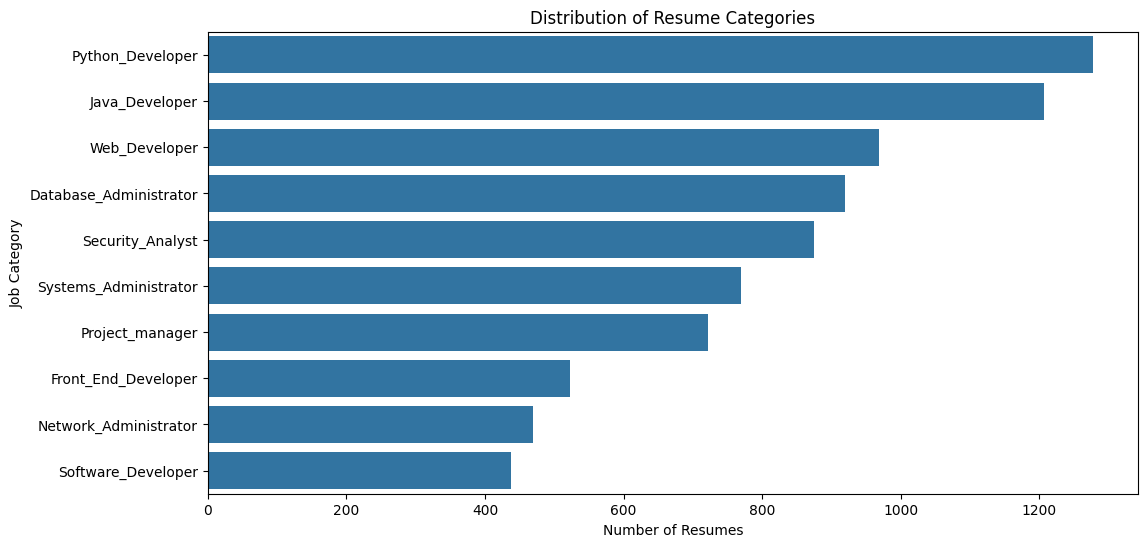

In [16]:
plt.figure(figsize=(12, 6))

sns.countplot(
    y=df["Category"],
    order=df["Category"].value_counts().index
)

plt.title("Distribution of Resume Categories")
plt.xlabel("Number of Resumes")
plt.ylabel("Job Category")

plt.show()

## Number of Resumes in Each Category

In [17]:
category_counts = df["Category"].value_counts()

category_counts

,count
Category,
Python_Developer,1278
Java_Developer,1206
Web_Developer,968
Database_Administrator,920
Security_Analyst,875
Systems_Administrator,769
Project_manager,722
Front_End_Developer,523
Network_Administrator,469


## Top 10 Resume Categories

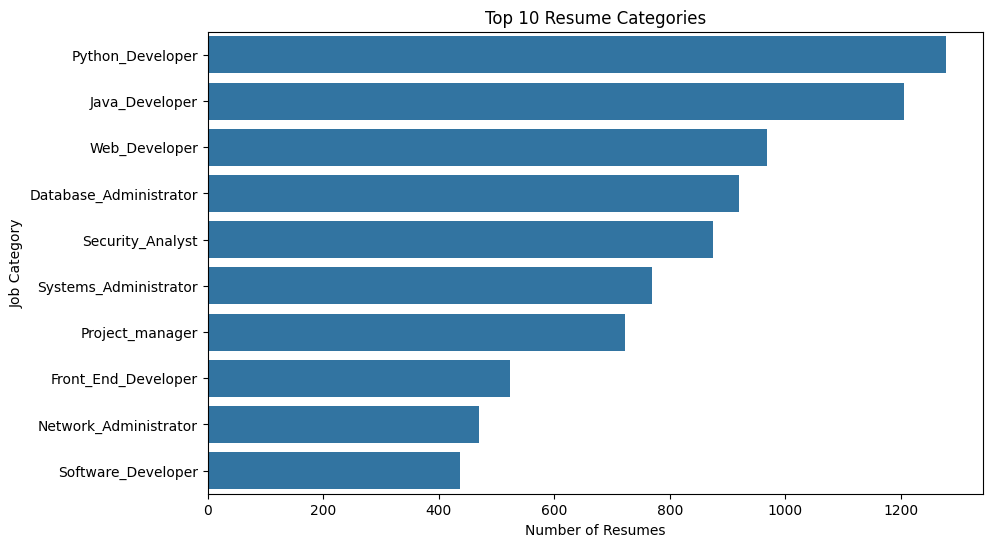

In [18]:
top_categories = df["Category"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Resume Categories")
plt.xlabel("Number of Resumes")
plt.ylabel("Job Category")

plt.show()

## Resume Text Length Analysis

In [19]:
df["Resume_Length"] = df["Resume"].astype(str).apply(len)

df[["Resume", "Resume_Length"]].head()

,Resume,Resume_Length
0,Python Developer Python Developer Philadelphia...,191
1,Python Developer Python Developer Python Devel...,3467
2,R&D Engineer R&D Engineer R&D Engineer - Nokia...,2812
3,Sr. Full Stack Developer Sr. Full Stack Develo...,16606
4,Sr. Full Stack Python Developer Sr. Full Stack...,9253


## Resume Length Distribution

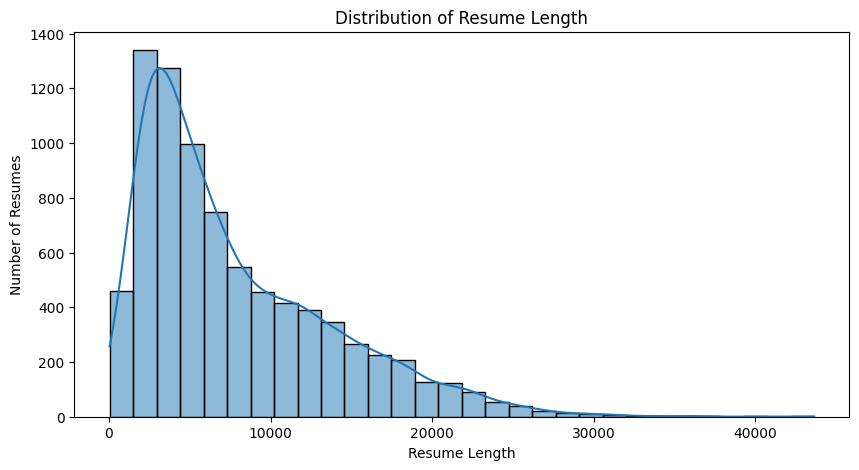

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Resume_Length"], bins=30, kde=True)

plt.title("Distribution of Resume Length")
plt.xlabel("Resume Length")
plt.ylabel("Number of Resumes")

plt.show()

## Average Resume Length by Job Category

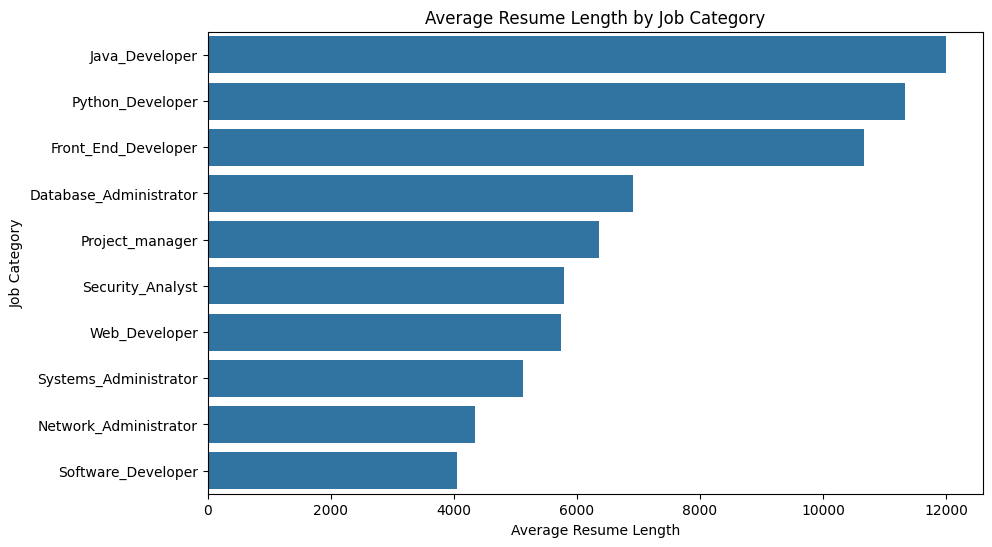

In [21]:
avg_length = (
    df.groupby("Category")["Resume_Length"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_length.values,
    y=avg_length.index
)

plt.title("Average Resume Length by Job Category")
plt.xlabel("Average Resume Length")
plt.ylabel("Job Category")

plt.show()

## Percentage Distribution of Resume Categories

In [22]:
category_percentage = (
    df["Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category_percentage

,proportion
Category,
Python_Developer,15.65
Java_Developer,14.77
Web_Developer,11.85
Database_Administrator,11.26
Security_Analyst,10.71
Systems_Administrator,9.42
Project_manager,8.84
Front_End_Developer,6.40
Network_Administrator,5.74


### Observation
The EDA helped identify the distribution of job categories and important patterns in the resume dataset.

# 7. **Resume Text Preprocessing**

## Import Library for Text Cleaning

In [23]:
import re

## Create Function to Clean Resume Text

In [24]:
import re

def clean_resume(text):
    # Convert input to string
    text = str(text)

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

## Apply Text Cleaning

In [25]:
df["Cleaned_Resume"] = df["Resume"].apply(clean_resume)

## Compare Original and Cleaned Resume Text

In [26]:
print("ORIGINAL RESUME:\n")
print(df["Resume"].iloc[0][:1000])

print("\n" + "="*80 + "\n")

print("CLEANED RESUME:\n")
print(df["Cleaned_Resume"].iloc[0][:1000])

ORIGINAL RESUME:

Python Developer Python Developer Philadelphia, PA Work Experience Python Developer December 2017 to Present Python Developer 2 Years Education Bachelor's in Computer Science Philadelphia, PA


CLEANED RESUME:

python developer python developer philadelphia pa work experience python developer december to present python developer years education bachelor s in computer science philadelphia pa


##  Check Cleaned Resume Data

In [27]:
df[["Resume", "Cleaned_Resume"]].head()

,Resume,Cleaned_Resume
0,Python Developer Python Developer Philadelphia...,python developer python developer philadelphia...
1,Python Developer Python Developer Python Devel...,python developer python developer python devel...
2,R&D Engineer R&D Engineer R&D Engineer - Nokia...,r d engineer r d engineer r d engineer nokia s...
3,Sr. Full Stack Developer Sr. Full Stack Develo...,sr full stack developer sr full stack develope...
4,Sr. Full Stack Python Developer Sr. Full Stack...,sr full stack python developer sr full stack p...


In [28]:
df["Cleaned_Resume"].isnull().sum()  # Check missing values

np.int64(0)

In [29]:
(df["Cleaned_Resume"].str.strip() == "").sum()  # Check empty resumes

np.int64(0)

# 8. **Job Category / Target Preparation**

## Check Job Categories

In [30]:
df["Category"].value_counts()  # Count resumes in each job category

,count
Category,
Python_Developer,1278
Java_Developer,1206
Web_Developer,968
Database_Administrator,920
Security_Analyst,875
Systems_Administrator,769
Project_manager,722
Front_End_Developer,523
Network_Administrator,469


## Check Number of Job Categories

In [31]:
df["Category"].nunique()  # Count unique job categories

10

## Display Unique Job Categories

In [32]:
df["Category"].unique()  # Display all job categories

array(['Python_Developer', 'Java_Developer', 'Front_End_Developer',
       'Network_Administrator', 'Project_manager', 'Security_Analyst',
       'Software_Developer', 'Systems_Administrator', 'Web_Developer',
       'Database_Administrator'], dtype=object)

## Encode Job Categories

In [33]:
label_encoder = LabelEncoder()

df["Category_Encoded"] = label_encoder.fit_transform(df["Category"])

## Check Encoded Job Categories

In [34]:
df[["Category", "Category_Encoded"]].head(10)

,Category,Category_Encoded
0,Python_Developer,5
1,Python_Developer,5
2,Python_Developer,5
3,Python_Developer,5
4,Python_Developer,5
5,Python_Developer,5
6,Python_Developer,5
7,Python_Developer,5
8,Python_Developer,5
9,Python_Developer,5


## Display Category Encoding Mapping

In [35]:
category_mapping = dict(
    zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
)

category_mapping

{'Database_Administrator': np.int64(0),
 'Front_End_Developer': np.int64(1),
 'Java_Developer': np.int64(2),
 'Network_Administrator': np.int64(3),
 'Project_manager': np.int64(4),
 'Python_Developer': np.int64(5),
 'Security_Analyst': np.int64(6),
 'Software_Developer': np.int64(7),
 'Systems_Administrator': np.int64(8),
 'Web_Developer': np.int64(9)}

# 9. **TF-IDF Feature Extraction**

## Create TF-IDF Vectorizer

In [36]:
tfidf = TfidfVectorizer(stop_words='english')

## Transform Resume Text into Numerical Features

In [37]:
X = tfidf.fit_transform(df["Cleaned_Resume"])

## Prepare Target Variable

In [38]:
y = df["Category_Encoded"]

## Check TF-IDF Feature Matrix Shape

In [39]:
print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (8167, 62745)


## Display TF-IDF Feature Matrix

In [40]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2973034 stored elements and shape (8167, 62745)>
  Coords	Values
  (0, 44270)	0.5563995788830612
  (0, 14883)	0.3691401371288231
  (0, 41561)	0.5500113733484805
  (0, 40138)	0.4211129015715109
  (0, 61548)	0.06063867334396012
  (0, 19457)	0.06063867334396012
  (0, 14098)	0.10915473838002782
  (0, 43051)	0.07064937817515148
  (0, 62292)	0.08411539787793262
  (0, 17257)	0.06557038364838956
  (0, 4824)	0.1100705099406615
  (0, 11145)	0.11149639452004137
  (0, 48761)	0.11884634457105728
  (1, 44270)	0.1944479050693073
  (1, 14883)	0.06450267852986837
  (1, 61548)	0.010595859024179118
  (1, 19457)	0.03178757707253735
  (1, 62292)	0.014698126600193578
  (1, 17257)	0.011457614472511842
  (1, 13563)	0.12202219652620007
  (1, 48769)	0.11695004150649764
  (1, 18131)	0.026588785090975346
  (1, 32697)	0.03536974634417964
  (1, 31264)	0.03100255674100183
  (1, 20996)	0.03680752640910971
  :	:
  (8166, 11113)	0.05260671814064183
  (8166, 

## Check Number of Extracted Features

In [41]:
print("Number of Features:", len(tfidf.get_feature_names_out()))

Number of Features: 62745


## Display Sample TF-IDF Features

In [42]:
print(tfidf.get_feature_names_out()[:20])

['aa' 'aaa' 'aaaa' 'aaae' 'aaas' 'aab' 'aaba' 'aac' 'aacc' 'aace' 'aacg'
 'aachen' 'aacounts' 'aad' 'aadhaar' 'aadhityaa' 'aadi' 'aadministrated'
 'aads' 'aadsync']


# 10. **Train-Test Split**

## Split the Dataset into Training and Testing Sets

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Check Training and Testing Data Shape

In [44]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (6533, 62745)
Testing Features  : (1634, 62745)
Training Labels   : (6533,)
Testing Labels    : (1634,)


## Display Number of Training and Testing Samples

In [45]:
print("Training Samples :", len(X_train.toarray()))
print("Testing Samples  :", len(X_test.toarray()))

Training Samples : 6533
Testing Samples  : 1634


## Verify Train-Test Split Ratio

In [46]:
total_samples = len(df)

train_percentage = (len(X_train.toarray()) / total_samples) * 100
test_percentage = (len(X_test.toarray()) / total_samples) * 100

print(f"Training Data : {train_percentage:.2f}%")
print(f"Testing Data  : {test_percentage:.2f}%")

Training Data : 79.99%
Testing Data  : 20.01%


# 11. **Logistic Regression Model**

## Train the Logistic Regression Model

In [47]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Predict Job Categories

In [48]:
y_pred_lr = logistic_model.predict(X_test)

## Calculate Model Accuracy

In [49]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 88.62 %


## Classification Report

In [50]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       195
           1       0.76      0.58      0.66       105
           2       0.99      0.98      0.99       247
           3       0.79      0.64      0.71        90
           4       0.89      0.95      0.92       132
           5       1.00      0.99      0.99       269
           6       0.98      0.97      0.98       182
           7       0.74      0.51      0.60        77
           8       0.77      0.89      0.82       149
           9       0.71      0.89      0.79       188

    accuracy                           0.89      1634
   macro avg       0.86      0.83      0.84      1634
weighted avg       0.89      0.89      0.88      1634



## Confusion Matrix

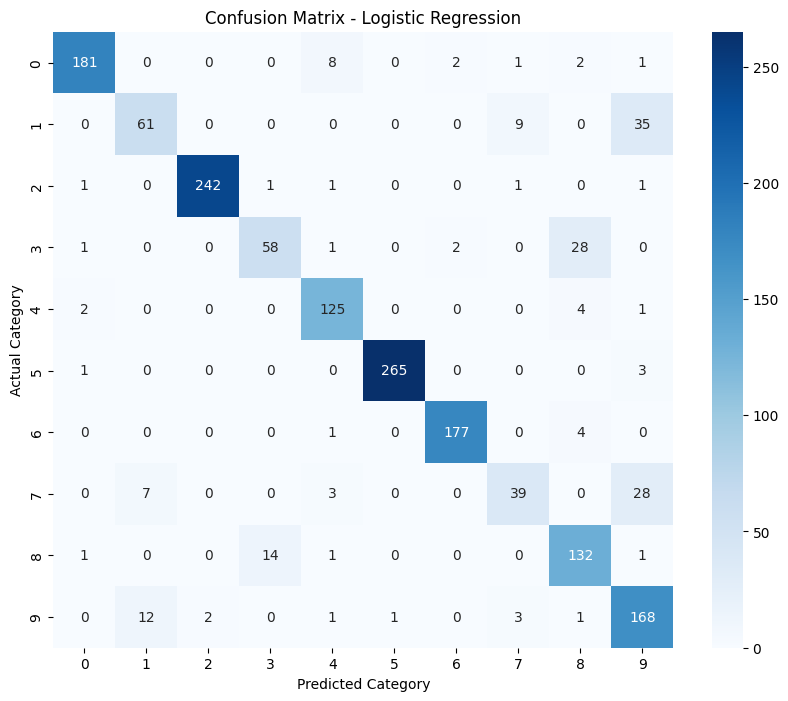

In [51]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.show()

## Compare Actual and Predicted Job Categories

In [52]:
comparison = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test[:10]),
    "Predicted": label_encoder.inverse_transform(y_pred_lr[:10])
})

comparison

,Actual,Predicted
0,Java_Developer,Java_Developer
1,Python_Developer,Python_Developer
2,Python_Developer,Python_Developer
3,Project_manager,Project_manager
4,Project_manager,Project_manager
5,Web_Developer,Web_Developer
6,Python_Developer,Python_Developer
7,Python_Developer,Python_Developer
8,Network_Administrator,Network_Administrator
9,Java_Developer,Java_Developer


# 12. **Decision Tree Classifier**

## Train the Decision Tree Model

In [53]:
# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Predict Job Categories

In [54]:
# Predict job categories for testing data
y_pred_dt = dt_model.predict(X_test)

## Calculate Model Accuracy

In [55]:
# Calculate model accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy : {dt_accuracy*100:.2f}%")

Decision Tree Accuracy : 85.19%


## Classification Report

In [56]:
# Display classification report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       195
           1       0.66      0.71      0.69       105
           2       0.95      0.93      0.94       247
           3       0.65      0.59      0.62        90
           4       0.89      0.93      0.91       132
           5       0.98      0.98      0.98       269
           6       0.94      0.94      0.94       182
           7       0.42      0.40      0.41        77
           8       0.73      0.79      0.76       149
           9       0.79      0.77      0.78       188

    accuracy                           0.85      1634
   macro avg       0.80      0.80      0.80      1634
weighted avg       0.85      0.85      0.85      1634



## Confusion Matrix

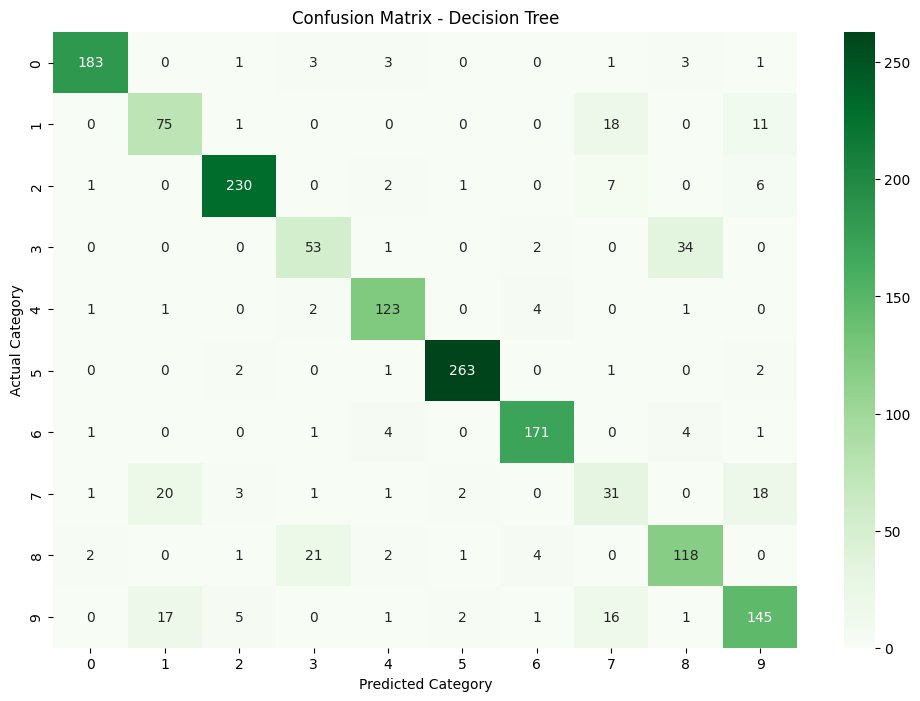

In [57]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.show()

## Compare Actual and Predicted Categories

In [58]:
actual = label_encoder.inverse_transform(y_test)

predicted = label_encoder.inverse_transform(y_pred_dt)

comparison = pd.DataFrame({
    "Actual Category": actual,
    "Predicted Category": predicted
})

comparison.head(10)

,Actual Category,Predicted Category
0,Java_Developer,Java_Developer
1,Python_Developer,Python_Developer
2,Python_Developer,Python_Developer
3,Project_manager,Project_manager
4,Project_manager,Project_manager
5,Web_Developer,Web_Developer
6,Python_Developer,Python_Developer
7,Python_Developer,Python_Developer
8,Network_Administrator,Systems_Administrator
9,Java_Developer,Java_Developer


# 13. **Random Forest Classifier**

## Train the Random Forest Model

In [59]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Predict Job Categories

In [60]:
# Predict job categories for testing data
y_pred_rf = rf_model.predict(X_test)

## Calculate Model Accuracy

In [61]:
# Calculate model accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy : {rf_accuracy*100:.2f}%")

Random Forest Accuracy : 86.41%


## Classification Report

In [62]:
# Display classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       195
           1       0.90      0.68      0.77       105
           2       0.98      0.98      0.98       247
           3       0.83      0.44      0.58        90
           4       0.90      0.93      0.92       132
           5       0.98      0.96      0.97       269
           6       0.96      0.94      0.95       182
           7       0.83      0.26      0.40        77
           8       0.67      0.92      0.77       149
           9       0.65      0.91      0.76       188

    accuracy                           0.86      1634
   macro avg       0.87      0.79      0.80      1634
weighted avg       0.88      0.86      0.86      1634



## Confusion Matrix

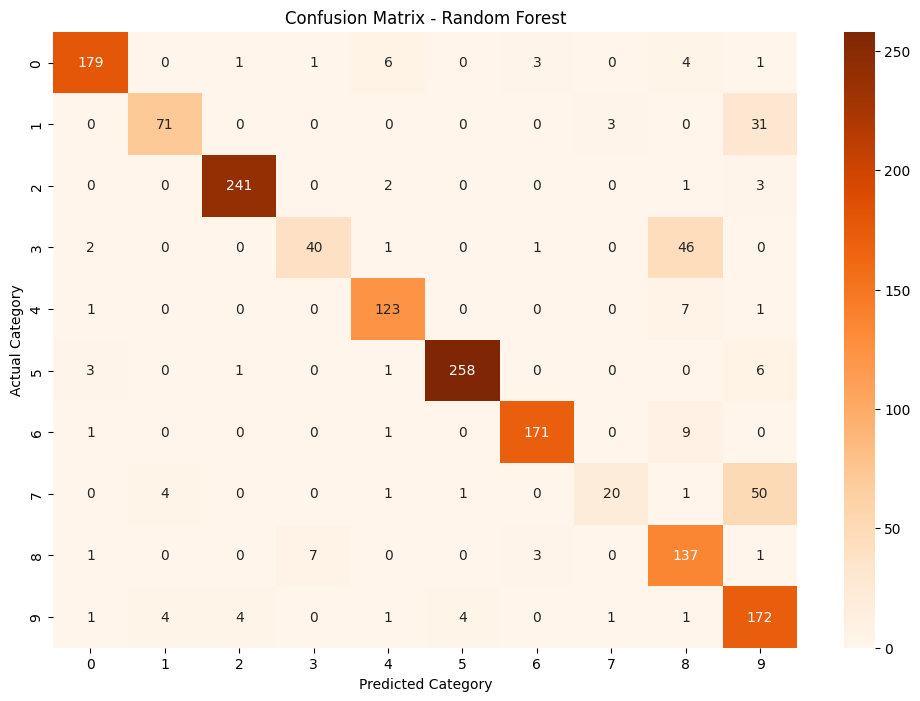

In [63]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.show()

## Compare Actual and Predicted Categories

In [64]:
actual = label_encoder.inverse_transform(y_test)

predicted = label_encoder.inverse_transform(y_pred_rf)

comparison = pd.DataFrame({
    "Actual Category": actual,
    "Predicted Category": predicted
})

comparison.head(10)

,Actual Category,Predicted Category
0,Java_Developer,Java_Developer
1,Python_Developer,Python_Developer
2,Python_Developer,Python_Developer
3,Project_manager,Project_manager
4,Project_manager,Project_manager
5,Web_Developer,Web_Developer
6,Python_Developer,Python_Developer
7,Python_Developer,Python_Developer
8,Network_Administrator,Systems_Administrator
9,Java_Developer,Java_Developer


# 14. **Multinomial Naive Bayes Classifier**

## Train the Multinomial Naive Bayes Model

In [65]:
# Import Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

MultinomialNB()

## Predict Job Categories

In [66]:
y_pred_nb = nb_model.predict(X_test)

## Calculate Model Accuracy

In [67]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f"Multinomial Naive Bayes Accuracy : {nb_accuracy*100:.2f}%")

Multinomial Naive Bayes Accuracy : 73.01%


## Classification Report

In [68]:
# Display classification report
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.96      0.73      0.83       195
           1       1.00      0.02      0.04       105
           2       0.74      0.96      0.84       247
           3       1.00      0.06      0.11        90
           4       0.80      0.87      0.84       132
           5       0.75      0.99      0.85       269
           6       0.90      0.93      0.92       182
           7       0.00      0.00      0.00        77
           8       0.57      0.93      0.71       149
           9       0.51      0.62      0.56       188

    accuracy                           0.73      1634
   macro avg       0.72      0.61      0.57      1634
weighted avg       0.75      0.73      0.67      1634



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix

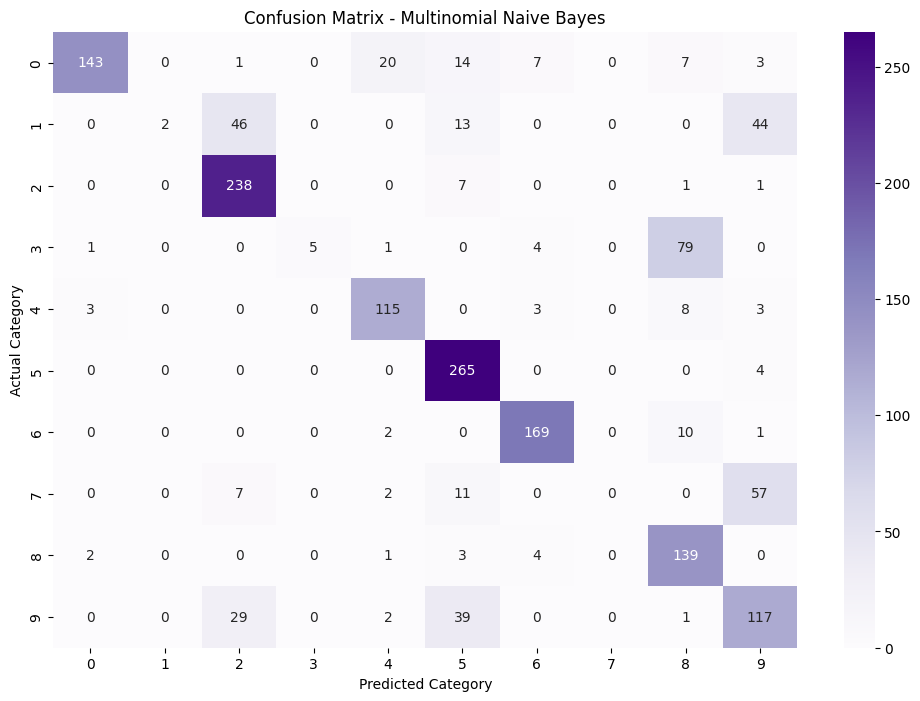

In [69]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.show()

## Compare Actual and Predicted Categories

In [70]:
actual = label_encoder.inverse_transform(y_test)

predicted = label_encoder.inverse_transform(y_pred_nb)

comparison = pd.DataFrame({
    "Actual Category": actual,
    "Predicted Category": predicted
})

comparison.head(10)

,Actual Category,Predicted Category
0,Java_Developer,Java_Developer
1,Python_Developer,Python_Developer
2,Python_Developer,Python_Developer
3,Project_manager,Project_manager
4,Project_manager,Project_manager
5,Web_Developer,Java_Developer
6,Python_Developer,Python_Developer
7,Python_Developer,Python_Developer
8,Network_Administrator,Systems_Administrator
9,Java_Developer,Java_Developer


# 15. **Model Comparison & Best Model Selection**

## Compare Machine Learning Models

In [71]:
# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Multinomial Naive Bayes"
    ],
    "Accuracy (%)": [
        lr_accuracy * 100,
        dt_accuracy * 100,
        rf_accuracy * 100,
        nb_accuracy * 100
    ]
})

model_comparison

,Model,Accuracy (%)
0,Logistic Regression,88.616891
1,Decision Tree,85.189718
2,Random Forest,86.413709
3,Multinomial Naive Bayes,73.011016


## Sort Models by Accuracy

In [72]:
model_comparison = model_comparison.sort_values(
    by="Accuracy (%)",
    ascending=False
)

model_comparison

,Model,Accuracy (%)
0,Logistic Regression,88.616891
2,Random Forest,86.413709
1,Decision Tree,85.189718
3,Multinomial Naive Bayes,73.011016


## Accuracy Comparison of Machine Learning Models

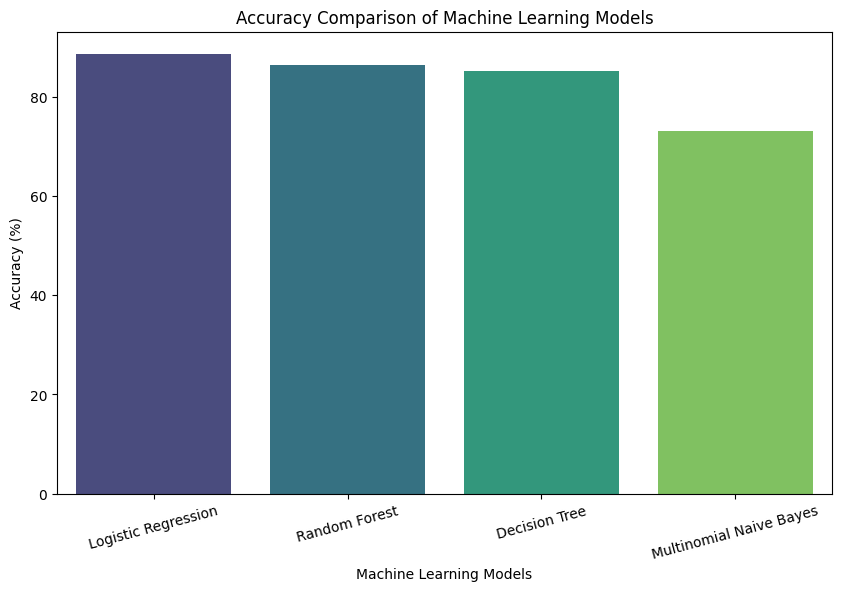

In [73]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy (%)",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=15)

plt.show()

## Select the Best Performing Model

In [74]:
best_model = model_comparison.iloc[0]

print("Best Model :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy (%)"],2), "%")

Best Model : Logistic Regression
Accuracy   : 88.62 %


### Observation
The four machine learning models were compared based on their performance, and the model with the highest accuracy was selected for final prediction.

# 16. **Predict Job Category Using New Resume Text**

### Create a Sample Resume

In [75]:
sample_resume = """
Python Developer

Skills:
Python
Machine Learning
SQL
Pandas
NumPy
Scikit-learn
TensorFlow
Data Analysis

Projects:
Credit Scoring Model
Heart Disease Prediction
AI Resume Screening System

Education:
Bachelor of Technology in Computer Science

Experience:
Machine Learning Internship
"""

## Clean the Resume Text

In [76]:
cleaned_resume = clean_resume(sample_resume)

print(cleaned_resume)

python developer skills python machine learning sql pandas numpy scikit learn tensorflow data analysis projects credit scoring model heart disease prediction ai resume screening system education bachelor of technology in computer science experience machine learning internship


## Convert Resume into TF-IDF Features

In [77]:
resume_vector = tfidf.transform([cleaned_resume])

## Predict Job Category

In [78]:
prediction = logistic_model.predict(resume_vector)

## Display Predicted Job Category

In [79]:
predicted_category = label_encoder.inverse_transform(prediction)

print("Predicted Job Category :", predicted_category[0])

Predicted Job Category : Python_Developer


# 17. **Upload Resume PDF**

## Install Required Library

In [80]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 100.5 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


## Import Required Libraries

In [81]:
import pdfplumber
from google.colab import files

## Upload Resume PDF

In [82]:
uploaded = files.upload()

Saving Vanshika_Soni_CV_Final (2).pdf to Vanshika_Soni_CV_Final (2).pdf


## Get Uploaded File Name

In [83]:
resume_file = list(uploaded.keys())[0]

print("Uploaded Resume :", resume_file)

Uploaded Resume : Vanshika_Soni_CV_Final (2).pdf


# 18. **Extract Text from Resume PDF**

## Open the Uploaded Resume

In [84]:
with pdfplumber.open(resume_file) as pdf:
    print("Resume opened successfully.")

Resume opened successfully.


## Extract Text from Resume

In [85]:
# Extract text from all pages

resume_text = ""

with pdfplumber.open(resume_file) as pdf:
    for page in pdf.pages:
        text = page.extract_text()

        if text:
            resume_text += text + "\n"

## Display Extracted Resume Text

In [86]:
print(resume_text[:2000])

VANSHIKA SONI
Ludhiana, Punjab | vanshikasoni441@gmail.com | +91 7508576350
LinkedIn: linkedin.com/in/vanshika-soni-3430b7344/|
GitHub: github.com/vxnshika-73
CAREER OBJECTIVE
Motivated and enthusiastic B.Tech CSE (AI &Machine Learning) student at CT University, seeking an
internship opportunity in Data Science / AI / ML to apply my academic knowledge, develop practical
skills, and contribute meaningfully to real-world projects.
TECHNICAL SKILLS
• Languages: Python, C, C++, SQL
• Machine Learning: EDA, Data Preprocessing, Feature Engineering, Model Training & Evaluation
• Libraries/Tools: Pandas, NumPy, Matplotlib, Jupyter Notebook
• Tools & Platforms: Git, GitHub, VS Code, Google Colab
• Database: MySQL
EDUCATION
Bachelor of Technology in Computer Science (AI & Data Science)
2024 – 2028 | CT University, Ludhiana | CGPA: 9.2 | 2nd Year (4th Semester)
• Relevant Coursework: Data Structures & Algorithms, Machine Learning, AI Fundamentals, Data
Analysis & Visualization, DBMS
Senior Second

## Check Resume Length

In [87]:
print("Total Characters:", len(resume_text))

Total Characters: 3537


## Verify Text Extraction

In [88]:
if len(resume_text) > 0:
    print("Resume text extracted successfully.")
else:
    print("No text found in the uploaded resume.")

Resume text extracted successfully.


# 19. **Predict Job Category from Uploaded Resume**


## Clean Extracted Resume Text

In [89]:
# Clean the extracted resume text
cleaned_uploaded_resume = clean_resume(resume_text)

print(cleaned_uploaded_resume[:1000])

vanshika soni ludhiana punjab linkedin linkedin com in vanshika soni b github github com vxnshika career objective motivated and enthusiastic b tech cse ai machine learning student at ct university seeking an internship opportunity in data science ai ml to apply my academic knowledge develop practical skills and contribute meaningfully to real world projects technical skills languages python c c sql machine learning eda data preprocessing feature engineering model training evaluation libraries tools pandas numpy matplotlib jupyter notebook tools platforms git github vs code google colab database mysql education bachelor of technology in computer science ai data science ct university ludhiana cgpa nd year th semester relevant coursework data structures algorithms machine learning ai fundamentals data analysis visualization dbms senior secondary xii cbse science stream passed secondary x cbse passed internship ai machine learning intern internsveda feb mar learned and applied fundamental

## Convert Resume Text into TF-IDF Features

In [90]:
uploaded_resume_vector = tfidf.transform([cleaned_uploaded_resume])

## Select Best Trained Model

In [91]:
print(model_comparison.columns)

Index(['Model', 'Accuracy (%)'], dtype='object')


In [92]:
trained_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Multinomial Naive Bayes": nb_model
}

# Get the best-performing model
best_model_name = model_comparison.iloc[0]["Model"]

# Select the trained model
final_model = trained_models[best_model_name]

print("Selected Model:", best_model_name)

Selected Model: Logistic Regression


## Predict Job Category

In [93]:
# Predict the job category
predicted_label = final_model.predict(uploaded_resume_vector)

# Convert encoded prediction back to job category
predicted_job_category = label_encoder.inverse_transform(predicted_label)

print("Predicted Job Category:", predicted_job_category[0])

Predicted Job Category: Python_Developer


## Final Prediction Result

In [94]:
print("=" * 55)
print("           AI RESUME SCREENING RESULT")
print("=" * 55)

print("Resume File            :", resume_file)
print("Model Used             :", best_model_name)
print("Predicted Job Category :", predicted_job_category[0])

print("=" * 55)

           AI RESUME SCREENING RESULT
Resume File            : Vanshika_Soni_CV_Final (2).pdf
Model Used             : Logistic Regression
Predicted Job Category : Python_Developer


### Observation
The uploaded resume was successfully processed, and the trained model predicted its job category based on the resume content.

# 20. **Skill Extraction from Resume**

## Create Skills List

In [95]:
skills_list = [
    "python",
    "java",
    "c++",
    "c",
    "javascript",
    "html",
    "css",
    "sql",
    "mysql",
    "mongodb",
    "git",
    "github",
    "machine learning",
    "deep learning",
    "artificial intelligence",
    "data science",
    "data analysis",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tensorflow",
    "keras",
    "pytorch",
    "power bi",
    "tableau",
    "excel",
    "flask",
    "django",
    "fastapi",
    "streamlit",
    "aws",
    "azure",
    "docker",
    "kubernetes"
]

## Create Skill Extraction Function

In [96]:
def extract_skills(text, skills):
    text = text.lower()
    found_skills = []

    for skill in skills:
        pattern = r'(?<!\w)' + re.escape(skill) + r'(?!\w)'

        if re.search(pattern, text):
            found_skills.append(skill)

    return found_skills

## Extract Skills from Uploaded Resume

In [97]:
detected_skills = extract_skills(resume_text, skills_list)

print("Detected Skills:")
print(detected_skills)

Detected Skills:
['python', 'c++', 'c', 'sql', 'mysql', 'git', 'github', 'machine learning', 'artificial intelligence', 'data science', 'pandas', 'numpy', 'matplotlib', 'seaborn']


## Display Detected Skills

In [98]:
print("Skills Found in Resume:")
print("-" * 30)

if detected_skills:
    for skill in detected_skills:
        print("✓", skill.title())
else:
    print("No predefined skills were detected.")

Skills Found in Resume:
------------------------------
✓ Python
✓ C++
✓ C
✓ Sql
✓ Mysql
✓ Git
✓ Github
✓ Machine Learning
✓ Artificial Intelligence
✓ Data Science
✓ Pandas
✓ Numpy
✓ Matplotlib
✓ Seaborn


## Count Detected Skills

In [99]:
print("Total Skills Detected:", len(detected_skills))

Total Skills Detected: 14


# 21. **Skill Gap Analysis & Recommendation**

## Define Skills for Different Job Roles

In [100]:
job_skills = {

    "Python_Developer": [
        "python",
        "sql",
        "git",
        "github",
        "flask",
        "django",
        "pandas",
        "numpy"
    ],

    "Java_Developer": [
        "java",
        "sql",
        "git",
        "github",
        "mysql"
    ],

    "Front_End_Developer": [
        "html",
        "css",
        "javascript",
        "git",
        "github"
    ],

    "Web_Developer": [
        "html",
        "css",
        "javascript",
        "sql",
        "git",
        "github"
    ],

    "Software_Developer": [
        "python",
        "java",
        "sql",
        "git",
        "github"
    ],

    "Database_Administrator": [
        "sql",
        "mysql",
        "mongodb"
    ],

    "Network_Administrator": [
        "networking",
        "linux",
        "security"
    ],

    "Systems_Administrator": [
        "linux",
        "networking",
        "aws",
        "azure"
    ],

    "Security_Analyst": [
        "security",
        "networking",
        "linux",
        "python"
    ],

    "Project_manager": [
        "project management",
        "excel",
        "communication",
        "leadership"
    ]
}

## Get Predicted Job Role

In [101]:
predicted_role = predicted_job_category[0]

print("Predicted Job Role:", predicted_role)

Predicted Job Role: Python_Developer


## Get Required Skills for Predicted Job Role

In [102]:
required_skills = job_skills.get(predicted_role, [])

print("Required Skills:")
print(required_skills)

Required Skills:
['python', 'sql', 'git', 'github', 'flask', 'django', 'pandas', 'numpy']


## Identify Matching and Missing Skills

In [103]:
matching_skills = [
    skill for skill in required_skills
    if skill in detected_skills
]

missing_skills = [
    skill for skill in required_skills
    if skill not in detected_skills
]

print("Matching Skills:", matching_skills)
print("Missing Skills:", missing_skills)

Matching Skills: ['python', 'sql', 'git', 'github', 'pandas', 'numpy']
Missing Skills: ['flask', 'django']


## Recommend Skills

In [104]:
print("Predicted Job Role:", predicted_role)

print("\nSkills Already Present:")
if matching_skills:
    for skill in matching_skills:
        print("✓", skill.title())
else:
    print("No matching skills detected.")

print("\nRecommended Skills to Develop:")
if missing_skills:
    for skill in missing_skills:
        print("•", skill.title())
else:
    print("All predefined skills for this role were detected.")

Predicted Job Role: Python_Developer

Skills Already Present:
✓ Python
✓ Sql
✓ Git
✓ Github
✓ Pandas
✓ Numpy

Recommended Skills to Develop:
• Flask
• Django


### Calculate Skill Match Percentage

In [105]:
if len(required_skills) > 0:
    skill_match_percentage = (
        len(matching_skills) / len(required_skills)
    ) * 100
else:
    skill_match_percentage = 0

print(f"Skill Match: {skill_match_percentage:.2f}%")

Skill Match: 75.00%


## Final Skill Analysis

In [106]:
print("=" * 55)
print("             SKILL GAP ANALYSIS")
print("=" * 55)

print("Predicted Job Role :", predicted_role)
print(f"Skill Match        : {skill_match_percentage:.2f}%")

print("\nMatching Skills:")
for skill in matching_skills:
    print("✓", skill.title())

print("\nRecommended Skills:")
for skill in missing_skills:
    print("•", skill.title())

print("=" * 55)

             SKILL GAP ANALYSIS
Predicted Job Role : Python_Developer
Skill Match        : 75.00%

Matching Skills:
✓ Python
✓ Sql
✓ Git
✓ Github
✓ Pandas
✓ Numpy

Recommended Skills:
• Flask
• Django


### Observation
The system identified the candidate's matching and missing skills for the predicted job role and calculated the skill match percentage.

# 23. **Save the Trained Model**

## Import Joblib

In [107]:
import joblib

## Save the Best Performing Model

In [108]:
joblib.dump(final_model, "best_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


## Save TF-IDF Vectorizer

In [109]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


## Save Label Encoder

In [110]:
joblib.dump(label_encoder, "label_encoder.pkl")

print("Label encoder saved successfully.")

Label encoder saved successfully.


## Check Saved Files

In [111]:
import os

saved_files = [
    "best_model.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl"
]

for file in saved_files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

✓ best_model.pkl
✓ tfidf_vectorizer.pkl
✓ label_encoder.pkl


# 24. **Load and Test Saved Model**


## Load Saved Model Components

In [112]:
loaded_model = joblib.load("best_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")

print("All model components loaded successfully.")

All model components loaded successfully.


## Prepare a Test Resume

In [113]:
test_resume = """
Python Developer with experience in Python, SQL, Git, GitHub,
Pandas, NumPy, Flask and web development.
"""

## Clean Test Resume

In [114]:
cleaned_test_resume = clean_resume(test_resume)

print(cleaned_test_resume)

python developer with experience in python sql git github pandas numpy flask and web development


## Transform Resume Using Saved TF-IDF Vectorizer

In [115]:
test_vector = loaded_tfidf.transform([cleaned_test_resume])

## Predict Job Category

In [116]:
test_prediction = loaded_model.predict(test_vector)

test_job_category = loaded_encoder.inverse_transform(test_prediction)

print("Predicted Job Category:", test_job_category[0])

Predicted Job Category: Python_Developer


## Model Verification

In [117]:
print("=" * 50)
print("        SAVED MODEL VERIFICATION")
print("=" * 50)

print("Model          : Loaded Successfully")
print("TF-IDF         : Loaded Successfully")
print("Label Encoder  : Loaded Successfully")
print("Prediction     :", test_job_category[0])

print("=" * 50)

        SAVED MODEL VERIFICATION
Model          : Loaded Successfully
TF-IDF         : Loaded Successfully
Label Encoder  : Loaded Successfully
Prediction     : Python_Developer


# 25. **Build the Streamlit Web Application**


##  Install Streamlit

In [118]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 88.5 MB/s eta 0:00:00


## Check Streamlit Installation

In [119]:
!streamlit --version

Streamlit, version 1.64.0


## Create Streamlit Application File

In [120]:
%%writefile app.py

import streamlit as st

# Page configuration
st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# Main title
st.title("AI Resume Screening & Job Recommendation System")

# Introduction
st.write(
    "Upload your resume to analyze your profile and receive "
    "job role predictions and skill recommendations."
)

st.divider()

# System features
st.subheader("System Features")

st.write("• Job Role Prediction")
st.write("• Resume Skill Extraction")
st.write("• Skill Gap Analysis")
st.write("• Skill Recommendations")
st.write("• Resume Match Score")

st.divider()

# Resume upload section
st.subheader("Upload Resume")

uploaded_resume = st.file_uploader(
    "Choose your resume",
    type=["pdf"]
)

# Check whether resume is uploaded
if uploaded_resume is not None:
    st.success("Resume uploaded successfully!")
    st.write("File Name:", uploaded_resume.name)

Writing app.py


## Check Application File

In [121]:
import os

if os.path.exists("app.py"):
    print("app.py created successfully.")
else:
    print("app.py not found.")

app.py created successfully.


## Check Application Code

In [122]:
with open("app.py", "r") as file:
    app_code = file.read()

print(app_code)


import streamlit as st

# Page configuration
st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# Main title
st.title("AI Resume Screening & Job Recommendation System")

# Introduction
st.write(
    "Upload your resume to analyze your profile and receive "
    "job role predictions and skill recommendations."
)

st.divider()

# System features
st.subheader("System Features")

st.write("• Job Role Prediction")
st.write("• Resume Skill Extraction")
st.write("• Skill Gap Analysis")
st.write("• Skill Recommendations")
st.write("• Resume Match Score")

st.divider()

# Resume upload section
st.subheader("Upload Resume")

uploaded_resume = st.file_uploader(
    "Choose your resume",
    type=["pdf"]
)

# Check whether resume is uploaded
if uploaded_resume is not None:
    st.success("Resume uploaded successfully!")
    st.write("File Name:", uploaded_resume.name)



## Run Streamlit Application

In [123]:
!pkill -f streamlit || true

^C


In [124]:
!streamlit run app.py --server.port 8501 > /content/logs.txt 2>&1 &

## Check Streamlit Server Status

In [125]:
!sleep 3
!cat /content/logs.txt



2026-09-30 11:56:41.846 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.229.255.68:8501



# 26. **Connect PDF Upload & Text Extraction**

## Install PDF Processing Library

In [126]:
!pip install pdfplumber -q

## Add PDF Text Extraction to Streamlit Application

In [127]:
%%writefile app.py

import streamlit as st
import pdfplumber

# --------------------------------------------------
# Page Configuration
# --------------------------------------------------

st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# --------------------------------------------------
# Main Title
# --------------------------------------------------

st.title("AI Resume Screening & Job Recommendation System")

st.write(
    "Upload your resume to analyze your profile, "
    "predict a suitable job category, and identify "
    "relevant skills."
)

st.divider()

# --------------------------------------------------
# Resume Upload
# --------------------------------------------------

st.subheader("📄 Upload Resume")

uploaded_resume = st.file_uploader(
    "Choose your resume",
    type=["pdf"]
)

# --------------------------------------------------
# Extract Text from PDF
# --------------------------------------------------

if uploaded_resume is not None:

    st.success("Resume uploaded successfully!")

    st.write("File Name:", uploaded_resume.name)

    resume_text = ""

    try:

        with pdfplumber.open(uploaded_resume) as pdf:

            for page in pdf.pages:

                text = page.extract_text()

                if text:
                    resume_text += text + "\n"

        # Check whether text was extracted

        if resume_text.strip():

            st.success("Resume text extracted successfully.")

            # Preview extracted text
            with st.expander("Preview Extracted Resume Text"):
                st.text(resume_text[:1500])

        else:

            st.warning(
                "No readable text was found in the uploaded resume."
            )

    except Exception as e:

        st.error("Unable to process the uploaded PDF.")
        st.write("Error:", e)

Overwriting app.py


## Check Updated Application File

In [128]:
import os

if os.path.exists("app.py"):
    print("Updated app.py exists successfully.")
else:
    print("app.py not found.")

Updated app.py exists successfully.


In [129]:
import streamlit
import pdfplumber

print("Streamlit:", streamlit.__version__)
print("pdfplumber: Installed successfully")

Streamlit: 1.64.0
pdfplumber: Installed successfully


## Restart Streamlit Application

In [130]:
!pkill -f streamlit || true

^C


In [131]:
!streamlit run app.py --server.port 8501 > /content/logs.txt 2>&1 &

In [132]:
!sleep 3
!cat /content/logs.txt

# 27. **Connect Trained ML Model to Streamlit**


## Check Saved Model Files

In [133]:
import os

required_files = [
    "best_model.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl"
]

for file in required_files:
    if os.path.exists(file):
        print("✓", file, "found")
    else:
        print("✗", file, "not found")

✓ best_model.pkl found
✓ tfidf_vectorizer.pkl found
✓ label_encoder.pkl found


## Install Joblib

In [134]:
!pip install joblib -q

## Load Saved ML Components

In [135]:
import joblib

loaded_model = joblib.load("best_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")
loaded_label_encoder = joblib.load("label_encoder.pkl")

print("ML model loaded successfully.")
print("TF-IDF vectorizer loaded successfully.")
print("Label encoder loaded successfully.")

ML model loaded successfully.
TF-IDF vectorizer loaded successfully.
Label encoder loaded successfully.


## Test Saved Model Prediction

In [136]:
test_resume = """
Python Developer with experience in Python, Machine Learning,
Pandas, NumPy, SQL, Git and Flask.
"""

cleaned_test_resume = clean_resume(test_resume)

test_vector = loaded_tfidf.transform([cleaned_test_resume])

test_prediction = loaded_model.predict(test_vector)

predicted_role = loaded_label_encoder.inverse_transform(test_prediction)

print("Predicted Job Role:", predicted_role[0])

Predicted Job Role: Python_Developer


## Connect ML Model to Streamlit Application

In [137]:
%%writefile app.py

import streamlit as st
import pdfplumber
import joblib
import re

# --------------------------------------------------
# Page Configuration
# --------------------------------------------------

st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# --------------------------------------------------
# Load Saved ML Components
# --------------------------------------------------

model = joblib.load("best_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# --------------------------------------------------
# Resume Cleaning Function
# --------------------------------------------------

def clean_resume(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# --------------------------------------------------
# Application Title
# --------------------------------------------------

st.title("AI Resume Screening & Job Recommendation System")

st.write(
    "Upload your resume to predict a suitable job role "
    "and analyze your skills."
)

st.divider()

# --------------------------------------------------
# Resume Upload
# --------------------------------------------------

st.subheader("📄 Upload Resume")

uploaded_resume = st.file_uploader(
    "Choose your resume",
    type=["pdf"]
)

# --------------------------------------------------
# Process Resume
# --------------------------------------------------

if uploaded_resume is not None:

    st.success("Resume uploaded successfully!")

    st.write("File Name:", uploaded_resume.name)

    resume_text = ""

    try:

        # Extract text from PDF
        with pdfplumber.open(uploaded_resume) as pdf:

            for page in pdf.pages:

                text = page.extract_text()

                if text:
                    resume_text += text + "\n"

        # Check extracted text
        if resume_text.strip():

            st.success("Resume text extracted successfully.")

            # Preview extracted text
            with st.expander("Preview Extracted Resume Text"):
                st.text(resume_text[:1500])

            # --------------------------------------------------
            # Clean Resume
            # --------------------------------------------------

            cleaned_text = clean_resume(resume_text)

            # --------------------------------------------------
            # Convert Resume to TF-IDF
            # --------------------------------------------------

            resume_vector = tfidf_vectorizer.transform(
                [cleaned_text]
            )

            # --------------------------------------------------
            # Predict Job Role
            # --------------------------------------------------

            prediction = model.predict(resume_vector)

            predicted_role = label_encoder.inverse_transform(
                prediction
            )[0]

            # --------------------------------------------------
            # Display Prediction
            # --------------------------------------------------

            st.divider()

            st.subheader("🎯 Predicted Job Role")

            st.success(predicted_role)

        else:

            st.warning(
                "No readable text was found in the uploaded resume."
            )

    except Exception as e:

        st.error("Unable to process the uploaded resume.")

        st.write("Error:", e)

Overwriting app.py


## Check Updated Application

In [138]:
import os

if os.path.exists("app.py"):
    print("Updated app.py created successfully.")
else:
    print("app.py not found.")

Updated app.py created successfully.


In [139]:
import os

for file in [
    "best_model.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl",
    "app.py"
]:
    print(file, "✓" if os.path.exists(file) else "✗")

best_model.pkl ✓
tfidf_vectorizer.pkl ✓
label_encoder.pkl ✓
app.py ✓


## Restart Streamlit Application

In [140]:
!pkill -f streamlit || true

^C


In [141]:
!streamlit run app.py --server.port 8501 > /content/logs.txt 2>&1 &

In [142]:
!sleep 3
!cat /content/logs.txt

#28. **Implement Skill Detection in the Streamlit Web Application**

## Add Skill List and Skill Extraction

In [143]:
%%writefile app.py

import streamlit as st
import pdfplumber
import joblib
import re

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# --------------------------------------------------
# LOAD TRAINED ML COMPONENTS
# --------------------------------------------------

model = joblib.load("best_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# --------------------------------------------------
# RESUME CLEANING FUNCTION
# --------------------------------------------------

def clean_resume(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --------------------------------------------------
# SKILL LIST
# --------------------------------------------------

skills_list = [
    "python",
    "java",
    "c++",
    "c#",
    "javascript",
    "typescript",
    "html",
    "css",
    "react",
    "angular",
    "node.js",
    "flask",
    "django",
    "fastapi",
    "sql",
    "mysql",
    "postgresql",
    "mongodb",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "keras",
    "pytorch",
    "machine learning",
    "deep learning",
    "nlp",
    "git",
    "github",
    "docker",
    "aws",
    "azure",
    "power bi",
    "tableau",
    "excel"
]

# --------------------------------------------------
# SKILL EXTRACTION FUNCTION
# --------------------------------------------------

def extract_skills(text):
    text_lower = text.lower()
    detected_skills = []

    for skill in skills_list:
        if skill.lower() in text_lower:
            detected_skills.append(skill)

    return sorted(set(detected_skills))

# --------------------------------------------------
# APPLICATION TITLE
# --------------------------------------------------

st.title("AI Resume Screening & Job Recommendation System")

st.write(
    "Upload your resume to predict a suitable job role "
    "and analyze your skills."
)

st.divider()

# --------------------------------------------------
# RESUME UPLOAD
# --------------------------------------------------

st.subheader("📄 Upload Resume")

uploaded_resume = st.file_uploader(
    "Choose your resume",
    type=["pdf"]
)

# --------------------------------------------------
# PROCESS RESUME
# --------------------------------------------------

if uploaded_resume is not None:

    st.success("Resume uploaded successfully!")

    st.write("File Name:", uploaded_resume.name)

    resume_text = ""

    try:

        # Extract text from PDF
        with pdfplumber.open(uploaded_resume) as pdf:

            for page in pdf.pages:

                text = page.extract_text()

                if text:
                    resume_text += text + "\n"

        # Check extracted text
        if resume_text.strip():

            st.success("Resume text extracted successfully.")

            # Preview
            with st.expander("Preview Extracted Resume Text"):
                st.text(resume_text[:1500])

            # --------------------------------------------------
            # JOB ROLE PREDICTION
            # --------------------------------------------------

            cleaned_text = clean_resume(resume_text)

            resume_vector = tfidf_vectorizer.transform(
                [cleaned_text]
            )

            prediction = model.predict(resume_vector)

            predicted_role = label_encoder.inverse_transform(
                prediction
            )[0]

            st.divider()

            st.subheader("🎯 Predicted Job Role")

            st.success(predicted_role)

            # --------------------------------------------------
            # SKILL DETECTION
            # --------------------------------------------------

            detected_skills = extract_skills(resume_text)

            st.divider()

            st.subheader("🛠️ Detected Skills")

            if detected_skills:

                st.write(
                    ", ".join(
                        skill.title()
                        for skill in detected_skills
                    )
                )

                st.info(
                    f"{len(detected_skills)} skills detected from the resume."
                )

            else:

                st.warning(
                    "No predefined skills were detected."
                )

        else:

            st.warning(
                "No readable text was found in the uploaded resume."
            )

    except Exception as e:

        st.error(
            "Unable to process the uploaded PDF."
        )

        st.write("Error:", e)

Overwriting app.py


## Check the Application File

In [144]:
!cat app.py


import streamlit as st
import pdfplumber
import joblib
import re

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# --------------------------------------------------
# LOAD TRAINED ML COMPONENTS
# --------------------------------------------------

model = joblib.load("best_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# --------------------------------------------------
# RESUME CLEANING FUNCTION
# --------------------------------------------------

def clean_resume(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# -----------------------

## Restart Streamlit

In [145]:
!pkill -f streamlit || true
!streamlit run app.py --server.port 8501 > /content/logs.txt 2>&1 &
!sleep 3
!cat /content/logs.txt

^C




#29. **Implement Skill Detection in the Streamlit Application**

## Update app.py

In [146]:
%%writefile app.py

import streamlit as st
import pdfplumber
import joblib
import re

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# --------------------------------------------------
# LOAD TRAINED ML COMPONENTS
# --------------------------------------------------

model = joblib.load("best_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# --------------------------------------------------
# RESUME CLEANING FUNCTION
# --------------------------------------------------

def clean_resume(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --------------------------------------------------
# SKILLS LIST
# --------------------------------------------------

skills_list = [
    "python",
    "java",
    "c++",
    "c#",
    "javascript",
    "typescript",
    "html",
    "css",
    "react",
    "angular",
    "node.js",
    "flask",
    "django",
    "fastapi",
    "sql",
    "mysql",
    "postgresql",
    "mongodb",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "keras",
    "pytorch",
    "machine learning",
    "deep learning",
    "nlp",
    "git",
    "github",
    "docker",
    "aws",
    "azure",
    "power bi",
    "tableau",
    "excel"
]

# --------------------------------------------------
# SKILL EXTRACTION FUNCTION
# --------------------------------------------------

def extract_skills(text):

    text_lower = text.lower()

    detected_skills = []

    for skill in skills_list:
        if skill.lower() in text_lower:
            detected_skills.append(skill)

    return sorted(set(detected_skills))

# --------------------------------------------------
# APPLICATION
# --------------------------------------------------

st.title("AI Resume Screening & Job Recommendation System")

st.write(
    "Upload your resume to predict a suitable job role "
    "and analyze your skills."
)

st.divider()

st.subheader("📄 Upload Resume")

uploaded_resume = st.file_uploader(
    "Choose your resume",
    type=["pdf"]
)

# --------------------------------------------------
# PROCESS RESUME
# --------------------------------------------------

if uploaded_resume is not None:

    st.success("Resume uploaded successfully!")

    st.write("File Name:", uploaded_resume.name)

    resume_text = ""

    try:

        # Extract text from PDF
        with pdfplumber.open(uploaded_resume) as pdf:

            for page in pdf.pages:

                text = page.extract_text()

                if text:
                    resume_text += text + "\n"

        if resume_text.strip():

            st.success("Resume text extracted successfully.")

            # Resume preview
            with st.expander("Preview Extracted Resume Text"):
                st.text(resume_text[:1500])

            # --------------------------------------------------
            # JOB ROLE PREDICTION
            # --------------------------------------------------

            cleaned_text = clean_resume(resume_text)

            resume_vector = tfidf_vectorizer.transform(
                [cleaned_text]
            )

            prediction = model.predict(resume_vector)

            predicted_role = label_encoder.inverse_transform(
                prediction
            )[0]

            st.divider()

            st.subheader("🎯 Predicted Job Role")

            st.success(predicted_role)

            # --------------------------------------------------
            # SKILL DETECTION
            # --------------------------------------------------

            detected_skills = extract_skills(resume_text)

            st.divider()

            st.subheader("🛠️ Detected Skills")

            if detected_skills:

                st.write(
                    ", ".join(
                        skill.title()
                        for skill in detected_skills
                    )
                )

                st.info(
                    f"{len(detected_skills)} skills detected "
                    "from the resume."
                )

            else:

                st.warning(
                    "No predefined skills were detected."
                )

        else:

            st.warning(
                "No readable text was found in the uploaded resume."
            )

    except Exception as e:

        st.error(
            "Unable to process the uploaded resume."
        )

        st.write("Error:", e)

Overwriting app.py


## Check app.py

In [147]:
!cat app.py


import streamlit as st
import pdfplumber
import joblib
import re

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# --------------------------------------------------
# LOAD TRAINED ML COMPONENTS
# --------------------------------------------------

model = joblib.load("best_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# --------------------------------------------------
# RESUME CLEANING FUNCTION
# --------------------------------------------------

def clean_resume(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# -----------------------

## Restart Streamlit

In [148]:
!pkill -f streamlit || true
!streamlit run app.py --server.port 8501 > /content/logs.txt 2>&1 &
!sleep 3
!cat /content/logs.txt

^C




#30. **Implement Skill Gap Analysis and Skill Recommendations**

## Create Job Role–Skill Mapping

In [149]:
# Required skills for each predicted job role

role_required_skills = {

    "Python_Developer": [
        "python",
        "sql",
        "pandas",
        "numpy",
        "machine learning",
        "git",
        "flask"
    ],

    "Java_Developer": [
        "java",
        "sql",
        "git",
        "javascript",
        "html",
        "css"
    ],

    "Web_Developer": [
        "html",
        "css",
        "javascript",
        "react",
        "node.js",
        "git"
    ],

    "Front_End_Developer": [
        "html",
        "css",
        "javascript",
        "react",
        "angular"
    ],

    "Software_Developer": [
        "python",
        "java",
        "sql",
        "git",
        "javascript"
    ],

    "Database_Administrator": [
        "sql",
        "mysql",
        "postgresql",
        "mongodb",
        "python"
    ],

    "Network_Administrator": [
        "networking",
        "linux",
        "tcp/ip",
        "firewall",
        "git"
    ],

    "Security_Analyst": [
        "cybersecurity",
        "networking",
        "linux",
        "firewall",
        "python"
    ],

    "Systems_Administrator": [
        "linux",
        "python",
        "networking",
        "docker",
        "aws"
    ],

    "Project_manager": [
        "excel",
        "power bi",
        "tableau",
        "git",
        "sql"
    ]
}

print("Job role skill mapping created successfully.")

Job role skill mapping created successfully.


## Add Skill Gap Analysis to app.py

In [150]:
%%writefile app.py

import streamlit as st
import pdfplumber
import joblib
import re

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# --------------------------------------------------
# LOAD TRAINED ML COMPONENTS
# --------------------------------------------------

model = joblib.load("best_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# --------------------------------------------------
# RESUME CLEANING FUNCTION
# --------------------------------------------------

def clean_resume(text):

    text = str(text)

    text = text.lower()

    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    text = re.sub(
        r'\S+@\S+',
        ' ',
        text
    )

    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text


# --------------------------------------------------
# SKILLS LIST
# --------------------------------------------------

skills_list = [

    "python",
    "java",
    "c++",
    "c#",
    "javascript",
    "typescript",
    "html",
    "css",
    "react",
    "angular",
    "node.js",
    "flask",
    "django",
    "fastapi",
    "sql",
    "mysql",
    "postgresql",
    "mongodb",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "keras",
    "pytorch",
    "machine learning",
    "deep learning",
    "nlp",
    "git",
    "github",
    "docker",
    "aws",
    "azure",
    "power bi",
    "tableau",
    "excel"

]


# --------------------------------------------------
# SKILL EXTRACTION FUNCTION
# --------------------------------------------------

def extract_skills(text):

    text_lower = text.lower()

    detected_skills = []

    for skill in skills_list:

        if skill.lower() in text_lower:

            detected_skills.append(skill)

    return sorted(set(detected_skills))


# --------------------------------------------------
# JOB ROLE REQUIRED SKILLS
# --------------------------------------------------

role_required_skills = {

    "Python_Developer": [
        "python",
        "sql",
        "pandas",
        "numpy",
        "machine learning",
        "git",
        "flask"
    ],

    "Java_Developer": [
        "java",
        "sql",
        "git",
        "javascript",
        "html",
        "css"
    ],

    "Web_Developer": [
        "html",
        "css",
        "javascript",
        "react",
        "node.js",
        "git"
    ],

    "Front_End_Developer": [
        "html",
        "css",
        "javascript",
        "react",
        "angular"
    ],

    "Software_Developer": [
        "python",
        "java",
        "sql",
        "git",
        "javascript"
    ],

    "Database_Administrator": [
        "sql",
        "mysql",
        "postgresql",
        "mongodb",
        "python"
    ],

    "Network_Administrator": [
        "networking",
        "linux",
        "tcp/ip",
        "firewall",
        "git"
    ],

    "Security_Analyst": [
        "cybersecurity",
        "networking",
        "linux",
        "firewall",
        "python"
    ],

    "Systems_Administrator": [
        "linux",
        "python",
        "networking",
        "docker",
        "aws"
    ],

    "Project_manager": [
        "excel",
        "power bi",
        "tableau",
        "git",
        "sql"
    ]

}


# --------------------------------------------------
# APPLICATION TITLE
# --------------------------------------------------

st.title(
    "AI Resume Screening & Job Recommendation System"
)

st.write(
    "Upload your resume to predict a suitable job role, "
    "detect your skills, and identify skill gaps."
)

st.divider()


# --------------------------------------------------
# RESUME UPLOAD
# --------------------------------------------------

st.subheader("📄 Upload Resume")

uploaded_resume = st.file_uploader(
    "Choose your resume",
    type=["pdf"]
)


# --------------------------------------------------
# PROCESS RESUME
# --------------------------------------------------

if uploaded_resume is not None:

    st.success(
        "Resume uploaded successfully!"
    )

    st.write(
        "File Name:",
        uploaded_resume.name
    )

    resume_text = ""

    try:

        # --------------------------------------------------
        # PDF TEXT EXTRACTION
        # --------------------------------------------------

        with pdfplumber.open(
            uploaded_resume
        ) as pdf:

            for page in pdf.pages:

                text = page.extract_text()

                if text:

                    resume_text += text + "\n"


        # --------------------------------------------------
        # CHECK RESUME TEXT
        # --------------------------------------------------

        if resume_text.strip():

            st.success(
                "Resume text extracted successfully."
            )


            # --------------------------------------------------
            # RESUME PREVIEW
            # --------------------------------------------------

            with st.expander(
                "Preview Extracted Resume Text"
            ):

                st.text(
                    resume_text[:1500]
                )


            # --------------------------------------------------
            # JOB ROLE PREDICTION
            # --------------------------------------------------

            cleaned_text = clean_resume(
                resume_text
            )

            resume_vector = (
                tfidf_vectorizer.transform(
                    [cleaned_text]
                )
            )

            prediction = model.predict(
                resume_vector
            )

            predicted_role = (
                label_encoder.inverse_transform(
                    prediction
                )[0]
            )


            st.divider()

            st.subheader(
                "🎯 Predicted Job Role"
            )

            st.success(
                predicted_role
            )


            # --------------------------------------------------
            # SKILL DETECTION
            # --------------------------------------------------

            detected_skills = extract_skills(
                resume_text
            )


            st.divider()

            st.subheader(
                "🛠️ Detected Skills"
            )


            if detected_skills:

                st.write(
                    ", ".join(
                        skill.title()
                        for skill in detected_skills
                    )
                )

                st.info(
                    f"{len(detected_skills)} skills detected "
                    "from the resume."
                )

            else:

                st.warning(
                    "No predefined skills were detected."
                )


            # --------------------------------------------------
            # REQUIRED SKILLS
            # --------------------------------------------------

            required_skills = (
                role_required_skills.get(
                    predicted_role,
                    []
                )
            )


            # --------------------------------------------------
            # SKILL GAP ANALYSIS
            # --------------------------------------------------

            if required_skills:

                detected_lower = [
                    skill.lower()
                    for skill in detected_skills
                ]

                matching_skills = []

                missing_skills = []


                for skill in required_skills:

                    if skill.lower() in detected_lower:

                        matching_skills.append(
                            skill
                        )

                    else:

                        missing_skills.append(
                            skill
                        )


                # --------------------------------------------------
                # SKILL MATCH PERCENTAGE
                # --------------------------------------------------

                skill_match_percentage = (
                    len(matching_skills)
                    / len(required_skills)
                ) * 100


                st.divider()

                st.subheader(
                    "📊 Skill Gap Analysis"
                )


                st.write(
                    "Required Skills for:",
                    predicted_role
                )


                st.write(
                    f"Skill Match: "
                    f"{skill_match_percentage:.2f}%"
                )


                st.progress(
                    int(skill_match_percentage)
                )


                # --------------------------------------------------
                # MATCHING SKILLS
                # --------------------------------------------------

                st.subheader(
                    "✅ Matching Skills"
                )


                if matching_skills:

                    st.write(
                        ", ".join(
                            skill.title()
                            for skill in matching_skills
                        )
                    )

                else:

                    st.info(
                        "No required skills matched."
                    )


                # --------------------------------------------------
                # MISSING SKILLS
                # --------------------------------------------------

                st.subheader(
                    "⚠️ Missing Skills"
                )


                if missing_skills:

                    st.write(
                        ", ".join(
                            skill.title()
                            for skill in missing_skills
                        )
                    )

                else:

                    st.success(
                        "All required skills were detected!"
                    )


                # --------------------------------------------------
                # SKILL RECOMMENDATIONS
                # --------------------------------------------------

                st.subheader(
                    "💡 Skill Recommendations"
                )


                if missing_skills:

                    st.write(
                        "Consider learning the following "
                        "skills to strengthen your profile:"
                    )

                    for skill in missing_skills:

                        st.markdown(
                            f"- **{skill.title()}**"
                        )

                else:

                    st.success(
                        "Your detected skills cover "
                        "the defined requirements for this role."
                    )


        else:

            st.warning(
                "No readable text was found "
                "in the uploaded resume."
            )


    except Exception as e:

        st.error(
            "Unable to process the uploaded resume."
        )

        st.write(
            "Error:",
            e
        )

Overwriting app.py


## Check the Updated app.py

In [151]:
!cat app.py


import streamlit as st
import pdfplumber
import joblib
import re

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# --------------------------------------------------
# LOAD TRAINED ML COMPONENTS
# --------------------------------------------------

model = joblib.load("best_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# --------------------------------------------------
# RESUME CLEANING FUNCTION
# --------------------------------------------------

def clean_resume(text):

    text = str(text)

    text = text.lower()

    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    text = re.sub(
        r'\S+@\S+',
        ' ',
        text
    )

    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        tex

## Check Required Model Files

In [152]:
import os

required_files = [
    "best_model.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl"
]

for file in required_files:

    if os.path.exists(file):

        print("✓", file, "found")

    else:

        print("✗", file, "not found")

✓ best_model.pkl found
✓ tfidf_vectorizer.pkl found
✓ label_encoder.pkl found


## Restart the Streamlit Application

In [153]:
!pkill -f streamlit || true
!streamlit run app.py --server.port 8501 > /content/logs.txt 2>&1 &
!sleep 3
!cat /content/logs.txt

^C




In [154]:
!cat /content/logs.txt

#31. **Implement Resume Match Score and Improve Web Interface**

## Update the Streamlit Application

In [155]:
%%writefile app.py

import streamlit as st
import pdfplumber
import joblib
import re

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# --------------------------------------------------
# LOAD TRAINED ML COMPONENTS
# --------------------------------------------------

model = joblib.load("best_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")


# --------------------------------------------------
# RESUME CLEANING FUNCTION
# --------------------------------------------------

def clean_resume(text):

    text = str(text)
    text = text.lower()

    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    text = re.sub(
        r'\S+@\S+',
        ' ',
        text
    )

    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text


# --------------------------------------------------
# SKILLS LIST
# --------------------------------------------------

skills_list = [
    "python",
    "java",
    "c++",
    "c#",
    "javascript",
    "typescript",
    "html",
    "css",
    "react",
    "angular",
    "node.js",
    "flask",
    "django",
    "fastapi",
    "sql",
    "mysql",
    "postgresql",
    "mongodb",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "keras",
    "pytorch",
    "machine learning",
    "deep learning",
    "nlp",
    "git",
    "github",
    "docker",
    "aws",
    "azure",
    "power bi",
    "tableau",
    "excel"
]


# --------------------------------------------------
# SKILL EXTRACTION FUNCTION
# --------------------------------------------------

def extract_skills(text):

    text_lower = text.lower()

    detected_skills = []

    for skill in skills_list:

        if skill.lower() in text_lower:
            detected_skills.append(skill)

    return sorted(set(detected_skills))


# --------------------------------------------------
# REQUIRED SKILLS FOR EACH ROLE
# --------------------------------------------------

role_required_skills = {

    "Python_Developer": [
        "python",
        "sql",
        "pandas",
        "numpy",
        "machine learning",
        "git",
        "flask"
    ],

    "Java_Developer": [
        "java",
        "sql",
        "git",
        "javascript",
        "html",
        "css"
    ],

    "Web_Developer": [
        "html",
        "css",
        "javascript",
        "react",
        "node.js",
        "git"
    ],

    "Front_End_Developer": [
        "html",
        "css",
        "javascript",
        "react",
        "angular"
    ],

    "Software_Developer": [
        "python",
        "java",
        "sql",
        "git",
        "javascript"
    ],

    "Database_Administrator": [
        "sql",
        "mysql",
        "postgresql",
        "mongodb",
        "python"
    ],

    "Network_Administrator": [
        "networking",
        "linux",
        "tcp/ip",
        "firewall",
        "git"
    ],

    "Security_Analyst": [
        "cybersecurity",
        "networking",
        "linux",
        "firewall",
        "python"
    ],

    "Systems_Administrator": [
        "linux",
        "python",
        "networking",
        "docker",
        "aws"
    ],

    "Project_manager": [
        "excel",
        "power bi",
        "tableau",
        "git",
        "sql"
    ]
}


# --------------------------------------------------
# APPLICATION TITLE
# --------------------------------------------------

st.title(
    "AI Resume Screening & Job Recommendation System"
)

st.write(
    "Upload your resume to predict a suitable job role, "
    "analyze your skills, and identify skill gaps."
)

st.divider()


# --------------------------------------------------
# RESUME UPLOAD
# --------------------------------------------------

st.subheader("📄 Upload Resume")

uploaded_resume = st.file_uploader(
    "Choose your resume",
    type=["pdf"]
)


# --------------------------------------------------
# PROCESS RESUME
# --------------------------------------------------

if uploaded_resume is not None:

    st.success("Resume uploaded successfully!")

    st.write(
        "File Name:",
        uploaded_resume.name
    )

    resume_text = ""

    try:

        # --------------------------------------------------
        # EXTRACT PDF TEXT
        # --------------------------------------------------

        with pdfplumber.open(uploaded_resume) as pdf:

            for page in pdf.pages:

                text = page.extract_text()

                if text:

                    resume_text += text + "\n"


        if resume_text.strip():

            st.success(
                "Resume text extracted successfully."
            )


            # --------------------------------------------------
            # RESUME PREVIEW
            # --------------------------------------------------

            with st.expander(
                "Preview Extracted Resume Text"
            ):

                st.text(
                    resume_text[:1500]
                )


            # --------------------------------------------------
            # JOB ROLE PREDICTION
            # --------------------------------------------------

            cleaned_text = clean_resume(
                resume_text
            )

            resume_vector = (
                tfidf_vectorizer.transform(
                    [cleaned_text]
                )
            )

            prediction = model.predict(
                resume_vector
            )

            predicted_role = (
                label_encoder.inverse_transform(
                    prediction
                )[0]
            )


            # --------------------------------------------------
            # SKILL DETECTION
            # --------------------------------------------------

            detected_skills = extract_skills(
                resume_text
            )


            # --------------------------------------------------
            # REQUIRED SKILLS
            # --------------------------------------------------

            required_skills = (
                role_required_skills.get(
                    predicted_role,
                    []
                )
            )


            # --------------------------------------------------
            # SKILL MATCH CALCULATION
            # --------------------------------------------------

            detected_lower = [
                skill.lower()
                for skill in detected_skills
            ]

            matching_skills = []

            missing_skills = []


            for skill in required_skills:

                if skill.lower() in detected_lower:

                    matching_skills.append(
                        skill
                    )

                else:

                    missing_skills.append(
                        skill
                    )


            if required_skills:

                skill_match_percentage = (
                    len(matching_skills)
                    / len(required_skills)
                ) * 100

            else:

                skill_match_percentage = 0


            # --------------------------------------------------
            # RESUME MATCH SCORE
            # --------------------------------------------------

            resume_match_score = round(
                skill_match_percentage,
                2
            )


            # --------------------------------------------------
            # RESULTS
            # --------------------------------------------------

            st.divider()

            st.subheader(
                "📊 Resume Analysis"
            )


            col1, col2 = st.columns(2)


            with col1:

                st.metric(
                    "Predicted Job Role",
                    predicted_role
                )


            with col2:

                st.metric(
                    "Resume Match Score",
                    f"{resume_match_score:.2f}%"
                )


            st.progress(
                int(resume_match_score)
            )


            # --------------------------------------------------
            # DETECTED SKILLS
            # --------------------------------------------------

            st.divider()

            st.subheader(
                "🛠️ Detected Skills"
            )


            if detected_skills:

                st.write(
                    ", ".join(
                        skill.title()
                        for skill in detected_skills
                    )
                )

            else:

                st.info(
                    "No predefined skills were detected."
                )


            # --------------------------------------------------
            # MATCHING SKILLS
            # --------------------------------------------------

            st.subheader(
                "✅ Matching Skills"
            )


            if matching_skills:

                st.write(
                    ", ".join(
                        skill.title()
                        for skill in matching_skills
                    )
                )

            else:

                st.info(
                    "No matching skills detected."
                )


            # --------------------------------------------------
            # MISSING SKILLS
            # --------------------------------------------------

            st.subheader(
                "⚠️ Missing Skills"
            )


            if missing_skills:

                for skill in missing_skills:

                    st.markdown(
                        f"- **{skill.title()}**"
                    )

            else:

                st.success(
                    "All defined required skills were detected!"
                )


            # --------------------------------------------------
            # SKILL RECOMMENDATIONS
            # --------------------------------------------------

            st.subheader(
                "💡 Skill Recommendations"
            )


            if missing_skills:

                st.write(
                    "Consider learning these skills "
                    "to strengthen your profile:"
                )

                for skill in missing_skills:

                    st.markdown(
                        f"➡️ **{skill.title()}**"
                    )

            else:

                st.success(
                    "No additional skills are currently "
                    "recommended based on the defined role requirements."
                )


        else:

            st.warning(
                "No readable text was found "
                "in the uploaded resume."
            )


    except Exception as e:

        st.error(
            "Unable to process the uploaded resume."
        )

        st.write(
            "Error:",
            e
        )

Overwriting app.py


## Check app.py

In [156]:
!cat app.py


import streamlit as st
import pdfplumber
import joblib
import re

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered"
)

# --------------------------------------------------
# LOAD TRAINED ML COMPONENTS
# --------------------------------------------------

model = joblib.load("best_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")


# --------------------------------------------------
# RESUME CLEANING FUNCTION
# --------------------------------------------------

def clean_resume(text):

    text = str(text)
    text = text.lower()

    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    text = re.sub(
        r'\S+@\S+',
        ' ',
        text
    )

    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        tex

## Restart Streamlit

In [157]:
!pkill -f streamlit || true
!streamlit run app.py --server.port 8501 > /content/logs.txt 2>&1 &
!sleep 3
!cat /content/logs.txt

^C




#32. **Add Error Handling and Perform Final Application Testing**

## Check Required Project Files

In [158]:
import os

required_files = [
    "app.py",
    "best_model.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl"
]

print("=" * 50)
print("        PROJECT FILE VERIFICATION")
print("=" * 50)

for file in required_files:
    if os.path.exists(file):
        print("✓", file, "found")
    else:
        print("✗", file, "NOT FOUND")

print("=" * 50)

        PROJECT FILE VERIFICATION
✓ app.py found
✓ best_model.pkl found
✓ tfidf_vectorizer.pkl found
✓ label_encoder.pkl found


## Check Python Libraries

In [159]:
import streamlit
import pdfplumber
import joblib
import sklearn

print("=" * 50)
print("        LIBRARY VERIFICATION")
print("=" * 50)

print("Streamlit       :", streamlit.__version__)
print("pdfplumber      : Installed")
print("joblib          : Installed")
print("scikit-learn    :", sklearn.__version__)

print("=" * 50)

        LIBRARY VERIFICATION
Streamlit       : 1.64.0
pdfplumber      : Installed
joblib          : Installed
scikit-learn    : 1.6.1


## Test the Saved ML Model

In [160]:
import joblib

loaded_model = joblib.load("best_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")
loaded_label_encoder = joblib.load("label_encoder.pkl")

test_resume = """
Python Developer with experience in Python,
Machine Learning, Pandas, NumPy, SQL, Git and Flask.
"""

test_vector = loaded_tfidf.transform([test_resume])

prediction = loaded_model.predict(test_vector)

predicted_role = loaded_label_encoder.inverse_transform(
    prediction
)[0]

print("Test Prediction:", predicted_role)

Test Prediction: Python_Developer


## Restart the Final Streamlit Application

In [161]:
!pkill -f streamlit || true
!streamlit run app.py --server.port 8501 > /content/logs.txt 2>&1 &
!sleep 5
!cat /content/logs.txt

^C




#33. **Create requirements.txt for Deployment**

##Check Installed Library Versions

In [162]:
import sys
import streamlit
import sklearn
import pandas
import numpy
import pdfplumber
import joblib

print("Python       :", sys.version)
print("Streamlit    :", streamlit.__version__)
print("Scikit-learn :", sklearn.__version__)
print("Pandas       :", pandas.__version__)
print("NumPy        :", numpy.__version__)
print("pdfplumber   : Installed")
print("joblib       : Installed")

Python       : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Streamlit    : 1.64.0
Scikit-learn : 1.6.1
Pandas       : 2.2.3
NumPy        : 2.1.3
pdfplumber   : Installed
joblib       : Installed


## Create requirements.txt

In [163]:
%%writefile requirements.txt

streamlit==1.64.0
pdfplumber
joblib
scikit-learn
pandas
numpy

Writing requirements.txt


## Check requirements.txt

In [164]:
!cat requirements.txt


streamlit==1.64.0
pdfplumber
joblib
scikit-learn
pandas
numpy


## Verify All Deployment Files

In [165]:
import os

deployment_files = [
    "app.py",
    "requirements.txt",
    "best_model.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl"
]

print("=" * 55)
print("          DEPLOYMENT FILE VERIFICATION")
print("=" * 55)

for file in deployment_files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file, "NOT FOUND")

print("=" * 55)

          DEPLOYMENT FILE VERIFICATION
✓ app.py
✓ requirements.txt
✓ best_model.pkl
✓ tfidf_vectorizer.pkl
✓ label_encoder.pkl


In [166]:
import os

project_folder = "/content/AI_Resume_Screening_Project"

os.makedirs(project_folder, exist_ok=True)

print("Project folder created successfully.")

Project folder created successfully.


In [167]:
import shutil
import os

files_to_copy = [
    "app.py",
    "requirements.txt",
    "best_model.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl"
]

for file in files_to_copy:

    source = f"/content/{file}"
    destination = f"{project_folder}/{file}"

    shutil.copy2(source, destination)

    print("Copied:", file)

Copied: app.py
Copied: requirements.txt
Copied: best_model.pkl
Copied: tfidf_vectorizer.pkl
Copied: label_encoder.pkl


In [168]:
print("Files in project folder:")
print()

for file in os.listdir(project_folder):
    print("✓", file)

Files in project folder:

✓ tfidf_vectorizer.pkl
✓ requirements.txt
✓ app.py
✓ label_encoder.pkl
✓ best_model.pkl


In [169]:
import os

project_folder = "/content/AI_Resume_Screening_Project"

folders = [
    "models",
    "notebooks",
    "data",
    "utils"
]

for folder in folders:
    os.makedirs(
        os.path.join(project_folder, folder),
        exist_ok=True
    )

print("Project folders created successfully.")

for folder in folders:
    print("✓", folder)

Project folders created successfully.
✓ models
✓ notebooks
✓ data
✓ utils


In [170]:
import shutil
import os

project_folder = "/content/AI_Resume_Screening_Project"

model_files = [
    "best_model.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl"
]

for file in model_files:

    source = os.path.join(project_folder, file)
    destination = os.path.join(
        project_folder,
        "models",
        file
    )

    if os.path.exists(source):
        shutil.move(source, destination)
        print("Moved:", file)
    else:
        print("Not found:", file)

Moved: best_model.pkl
Moved: tfidf_vectorizer.pkl
Moved: label_encoder.pkl
